In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import statsmodels.api as sm
import math
from scipy import stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import plotly.io as pio
pio.renderers.default = "kaggle"
import os

from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder


In [44]:
import os
from pathlib import Path

# Anchor to project root whether Jupyter is launched from scripts/ or rds_project/
nb_file = globals().get("__vsc_ipynb_file__")
if nb_file:
    os.chdir(Path(nb_file).parent.parent)
else:
    root = Path.cwd()
    while not (root / "data").exists() and root.parent != root:
        root = root.parent
    os.chdir(root)

print("Working directory:", os.getcwd())

Current directory: /Users/georgebuck/Desktop/rds_project


In [45]:
train =  pd.read_csv(r"data/playground-series-s6e1/train.csv").drop(columns="id",axis=1,)
test = pd.read_csv(r"data/playground-series-s6e1/test.csv").drop(columns="id",axis=1,)
sub = pd.read_csv(r"data/playground-series-s6e1/sample_submission.csv")

In [46]:
train

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.300
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.700
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.000
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.900
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.000
...,...,...,...,...,...,...,...,...,...,...,...,...
629995,18,female,b.tech,4.86,70.7,yes,4.1,good,mixed,high,moderate,69.500
629996,21,female,ba,7.08,54.4,yes,4.5,average,mixed,low,moderate,78.900
629997,24,male,bca,0.64,44.2,yes,4.3,poor,online videos,low,moderate,19.599
629998,20,male,b.com,1.54,75.1,yes,8.2,average,group study,high,moderate,59.100


In [47]:
train.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,20.545821,4.002337,71.987261,7.072758,62.506672
std,2.260238,2.359880,17.430098,1.744811,18.916884
min,17.000000,0.080000,40.600000,4.100000,19.599000
25%,19.000000,1.970000,57.000000,5.600000,48.800000
50%,21.000000,4.000000,72.600000,7.100000,62.600000
75%,23.000000,6.050000,87.200000,8.600000,76.300000
max,24.000000,7.910000,99.400000,9.900000,100.000000


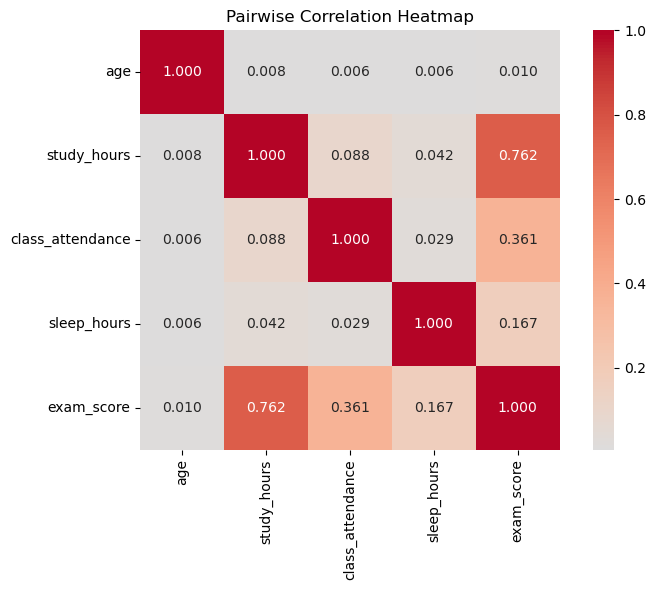

In [48]:
corr_matrix = train.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm", 
            center=0, square=True, ax=ax)
ax.set_title("Pairwise Correlation Heatmap")
plt.tight_layout()
plt.show()

## Dataset Overview
- This dataset contains academic performance and lifestyle data for 630,000 students to analyze factors influencing exam success.

#### Column Descriptions
- id: A unique identifier assigned to each individual student record in the dataset.

- age: The chronological age of the student, ranging from 17 to 24 years.

- gender: The self-identified gender of the student (Male, Female, or Other).

- course: The specific academic program or degree the student is currently enrolled in.

- study_hours: The average number of hours the student spends studying on a daily basis.

- class_attendance: The percentage of scheduled classes the student has attended.

- internet_access: Indicates whether the student has a reliable internet connection for study (Yes/No).

- sleep_hours: The average duration of sleep the student gets per night.

- sleep_quality: A subjective rating of the student's sleep restorative value (Poor, Average, Good).

- study_method: The primary technique used for learning (e.g., Self-study, Coaching, Online videos).

- facility_rating: The student's assessment of their educational environment's quality (Low, Medium, High).

- exam_difficulty: The perceived or categorized level of challenge for the examination (Easy, Moderate, Hard).

- exam_score: The final numerical mark achieved by the student (The target variable for prediction).

In [49]:
data_des = train.select_dtypes(include='number').agg(['mean', 'std', 'median']).T

In [50]:
df_plot = data_des.reset_index()

In [51]:
fig = px.bar(
    df_plot, 
    x="index", 
    y=["mean", "median", "std"], 
    barmode="group", 
    log_y=True, 
    title="Comparison between Mean, Median and Standard Deviation",
    labels={"index": "Study Method", "value": "Score/Value", "variable": "Statistic"},
    template="plotly_dark"
)

fig.show(renderer="kaggle")

In [52]:
def cat_tar(df, target_col="exam_score"):
    cat_cols = df.select_dtypes("object").columns
    n_features = len(cat_cols)
    num_cols = math.ceil(n_features / 2)
    
    fig = make_subplots(
        rows=2, 
        cols=num_cols, 
        subplot_titles=[f"{c} vs {target_col}" for c in cat_cols]
    )

    for i, col_name in enumerate(cat_cols):
        curr_row = (i % 2) + 1
        curr_col = (i // 2) + 1
        
        data = df.groupby(col_name)[target_col].mean().reset_index().sort_values(by=target_col, ascending=False)
        
        fig.add_trace(
            go.Bar(
                x=data[col_name], 
                y=data[target_col], 
                name=col_name
            ),
            row=curr_row, 
            col=curr_col
        )

    fig.update_layout(
        height=900,
        title_text="Categorical Analysis vs Target", 
        showlegend=False
    )
    fig.show(renderer="kaggle")


In [53]:
cat_tar(train)

In [54]:
def data_summary(df):
    num_col = df.select_dtypes("number").columns
    num_col = num_col[num_col != "exam_score"]
    X = df[num_col]
    y = df['exam_score']
    model = sm.OLS(y, X.astype(float)).fit()
    return model.summary()

    
    

In [55]:
data_summary(train)

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:             exam_score   R-squared (uncentered):                   0.973
Model:                            OLS   Adj. R-squared (uncentered):              0.973
Method:                 Least Squares   F-statistic:                          5.777e+06
Date:                Mon, 04 May 2026   Prob (F-statistic):                        0.00
Time:                        17:59:53   Log-Likelihood:                     -2.3836e+06
No. Observations:              630000   AIC:                                  4.767e+06
Df Residuals:                  629996   BIC:                                  4.767e+06
Df Model:                           4                                                  
Covariance Type:            nonrobust                                                  
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
age                  0.2241      0.003     69.039      0.000       0.218       0.230
study_hours          5.8850      0.006   1036.880      0.000       5.874       5.896
class_attendance     0.3294      0.001    456.594      0.000       0.328       0.331
sleep_hours          1.4966      0.007    208.143      0.000       1.483       1.511
==============================================================================
Omnibus:                      327.438   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              301.928
Skew:                           0.023   Prob(JB):                     2.74e-66
Kurtosis:                       2.903   Cond. No.                         43.1
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [56]:
train.corr(numeric_only=True)

,age,study_hours,class_attendance,sleep_hours,exam_score
age,1.000000,0.007545,0.005628,0.005864,0.010472
study_hours,0.007545,1.000000,0.087617,0.042491,0.762267
class_attendance,0.005628,0.087617,1.000000,0.029263,0.360954
sleep_hours,0.005864,0.042491,0.029263,1.000000,0.167410
exam_score,0.010472,0.762267,0.360954,0.167410,1.000000


# T Test

In [57]:
internet_yes = train[train['internet_access'] == 'yes']['exam_score']
internet_no = train[train['internet_access'] == 'no']['exam_score']

t_stat, p_val = stats.ttest_ind(internet_yes, internet_no)

print(f"T-Statistic: {t_stat}, P-Value: {p_val}")

T-Statistic: 0.35496949770317443, P-Value: 0.7226125612563572


# One-way ANOVA

In [58]:
self_study = train[train['study_method'] == 'self-study']['exam_score']
coaching = train[train['study_method'] == 'coaching']['exam_score']
group_study = train[train['study_method'] == 'group study']['exam_score']
online_videos = train[train['study_method'] == 'online videos']['exam_score']
mixed = train[train['study_method'] == 'mixed']['exam_score']

f_stat, p_val = stats.f_oneway(self_study, coaching, group_study,online_videos ,mixed)

print(f"F-Statistic: {f_stat}, P-Value: {p_val}")

F-Statistic: 8304.288535811489, P-Value: 0.0


# Chi-Square Test 

In [59]:
contingency_table = pd.crosstab(train['gender'], train['exam_difficulty'])

chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)

print(f"Chi2 Statistic: {chi2}, P-Value: {p_val}")

Chi2 Statistic: 40.81660068053178, P-Value: 2.933391073825853e-08


In [60]:
tukey = pairwise_tukeyhsd(endog=train['exam_score'],      
                          groups=train['study_method'],   
                          alpha=0.05)                     

print(tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05        
    group1        group2    meandiff p-adj  lower    upper   reject
-------------------------------------------------------------------
     coaching   group study  -8.7348   0.0  -8.9342  -8.5354   True
     coaching         mixed  -4.1649   0.0  -4.3643  -3.9655   True
     coaching online videos  -9.5391   0.0  -9.7393  -9.3388   True
     coaching    self-study -11.5665   0.0 -11.7627 -11.3703   True
  group study         mixed   4.5699   0.0   4.3671   4.7727   True
  group study online videos  -0.8042   0.0  -1.0078  -0.6006   True
  group study    self-study  -2.8317   0.0  -3.0313  -2.6321   True
        mixed online videos  -5.3741   0.0  -5.5777  -5.1706   True
        mixed    self-study  -7.4016   0.0  -7.6012   -7.202   True
online videos    self-study  -2.0275   0.0  -2.2279   -1.827   True
-------------------------------------------------------------------


In [61]:
strange_students = train[(train['study_hours'] < 1) & (train['exam_score'] > 90)]
display(strange_students[['study_hours', 'exam_score', 'study_method']])

,study_hours,exam_score,study_method
51537,0.47,100.0,coaching
75952,0.08,93.5,group study
78392,0.86,100.0,online videos
80139,0.40,91.7,coaching
117555,0.08,93.4,coaching
194976,0.08,91.5,coaching
198833,0.28,97.5,coaching
258607,0.80,99.9,coaching
300877,0.90,91.6,coaching
307262,0.86,92.5,coaching


# model training 

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

_le  = LabelEncoder()
_cat = ['gender', 'course', 'internet_access', 'sleep_quality',
        'study_method', 'facility_rating', 'exam_difficulty']

_train_enc = train.copy()
_test_enc  = test.copy()
for col in _cat:
    _train_enc[col] = _le.fit_transform(train[col])
    _test_enc[col]  = _le.transform(test[col])

_X = _train_enc.drop(columns=['exam_score'])
_y = _train_enc['exam_score']
X_train, X_test, y_train, y_test = train_test_split(
    _X, _y, test_size=0.2, random_state=42)

model = HistGradientBoostingRegressor(
    max_iter=1000, learning_rate=0.05, max_depth=10, random_state=42)
print('Training HistGBR...')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'R²: {r2:.4f}  MAE: {mae:.4f}')


In [ ]:
sub['exam_score'] = model.predict(_test_enc)
sub.to_csv('data/playground-series-s6e1/marks.csv', index=False)
print('Submission saved.')

# Fairness Analysis

This section audits the **existing trained model** for algorithmic unfairness across protected and sensitive attributes — no retraining. We apply seven complementary lenses:

| # | Test | What it measures |
|---|------|-----------------|
| 0 | **Setup** | Decode group labels from the encoded test split |
| 1 | **Data-level bias** | Are raw score distributions skewed across genders? |
| 2 | **Error parity** | Is MAE / RMSE / bias equal across groups? |
| 3 | **Demographic parity** | Do all groups get the same predicted pass rate? |
| 4 | **Equal opportunity / equalized odds** | Are TPR and FPR equal across groups? |
| 5 | **Counterfactual fairness** | Does flipping only gender change predictions? |
| 6 | **Feature importance** | Does the model rely heavily on the protected attribute? |
| 7 | **Socioeconomic proxy** | Does the model amplify internet-access gaps? |

**Protected attributes tested:** `gender` (female / male / other), `internet_access` (socioeconomic proxy)

In [ ]:
#  FAIRNESS SETUP 
# Audits the existing trained model — no retraining.
# Uses: model, X_train, X_test, y_train, y_test, y_pred from cells above.
import numpy as np
import matplotlib.pyplot as plt

# LabelEncoder sorts classes alphabetically, so the mappings are deterministic:
#   gender:          female=0, male=1, other=2
#   internet_access: no=0,     yes=1
gender_decode   = {0: 'female', 1: 'male', 2: 'other'}
internet_decode = {0: 'no',     1: 'yes'}

gender_test   = X_test['gender'].map(gender_decode).values
internet_test = X_test['internet_access'].map(internet_decode).values
y_test_arr    = y_test.values

THRESHOLD = float(y_train.mean())
GENDERS   = ['female', 'male', 'other']

print('Auditing existing model (no retraining)')
print(f'Test set size:                      {len(y_test_arr):,}')
r2 = 1 - np.sum((y_test_arr - y_pred)**2) / np.sum((y_test_arr - y_test_arr.mean())**2)
print(f'Model R²:                           {r2:.4f}')
print(f'Pass/fail threshold (train mean):   {THRESHOLD:.2f}')
print(f'Gender distribution: { {g: int((gender_test == g).sum()) for g in GENDERS} }')


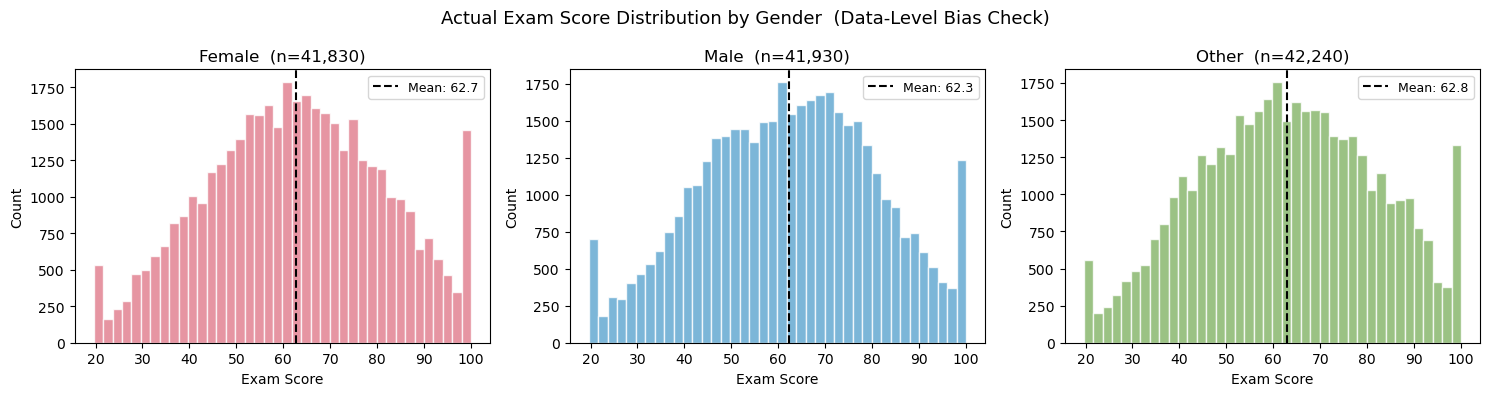


Actual score statistics by gender (test split):
Gender            n     Mean      Std   Median
female       41,830    62.71    18.83    62.60
male         41,930    62.29    18.73    62.70
other        42,240    62.81    19.01    62.80


In [ ]:
#  1. DATA BIAS CHECK: Actual Score Distributions by Gender 
palette = {'female': '#e07b8b', 'male': '#5ba4cf', 'other': '#82b366'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Actual Exam Score Distribution by Gender  (Data-Level Bias Check)", fontsize=13)
for ax, g in zip(axes, GENDERS):
    mask     = gender_test == g
    mean_val = y_test_arr[mask].mean()
    ax.hist(y_test_arr[mask], bins=40, color=palette[g], alpha=0.8, edgecolor='white')
    ax.axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.set_title(f"{g.capitalize()}  (n={mask.sum():,})")
    ax.set_xlabel("Exam Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("\nActual score statistics by gender (test split):")
print(f"{'Gender':<10} {'n':>8} {'Mean':>8} {'Std':>8} {'Median':>8}")
for g in GENDERS:
    mask = gender_test == g
    s    = y_test_arr[mask]
    print(f"{g:<10} {mask.sum():>8,} {s.mean():>8.2f} {s.std():>8.2f} {np.median(s):>8.2f}")

Error Parity by Gender:
Gender          MAE     RMSE     Bias  (positive bias = over-prediction)
female         7.00     8.77    -0.04
male           6.99     8.76    -0.05
other          7.01     8.79    +0.01

MAE spread  (max − min): 0.023
Bias spread (max − min): 0.062


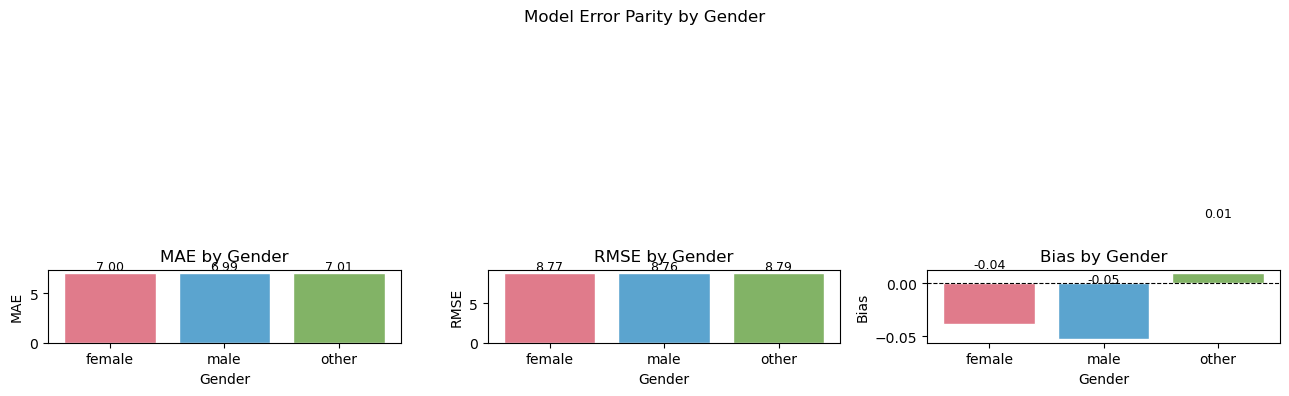

In [ ]:
#  2. ERROR PARITY BY GENDER (Model Performance Fairness) 
mae_by_g  = {g: mean_absolute_error(y_test_arr[gender_test == g], y_pred[gender_test == g]) for g in GENDERS}
rmse_by_g = {g: np.sqrt(np.mean((y_test_arr[gender_test == g] - y_pred[gender_test == g])**2)) for g in GENDERS}
bias_by_g = {g: np.mean(y_pred[gender_test == g] - y_test_arr[gender_test == g]) for g in GENDERS}

print("Error Parity by Gender:")
print(f"{'Gender':<10} {'MAE':>8} {'RMSE':>8} {'Bias':>8}  (positive bias = over-prediction)")
for g in GENDERS:
    print(f"{g:<10} {mae_by_g[g]:>8.2f} {rmse_by_g[g]:>8.2f} {bias_by_g[g]:>+8.2f}")
print(f"\nMAE spread  (max − min): {max(mae_by_g.values()) - min(mae_by_g.values()):.3f}")
print(f"Bias spread (max − min): {max(bias_by_g.values()) - min(bias_by_g.values()):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (metric, vals) in zip(axes, [("MAE", mae_by_g), ("RMSE", rmse_by_g), ("Bias", bias_by_g)]):
    bars = ax.bar(GENDERS, [vals[g] for g in GENDERS],
                  color=[palette[g] for g in GENDERS], edgecolor='white')
    ax.set_title(f"{metric} by Gender")
    ax.set_xlabel("Gender")
    ax.set_ylabel(metric)
    for bar, g in zip(bars, GENDERS):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05, f'{vals[g]:.2f}',
                ha='center', va='bottom', fontsize=9)
    if metric == "Bias":
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.suptitle("Model Error Parity by Gender", fontsize=12)
plt.tight_layout()
plt.show()

Pass/fail threshold (training mean): 62.5

Gender       Actual pass rate  Predicted pass rate
female                  0.502                0.507
male                    0.504                0.504
other                   0.506                0.510

Demographic Parity Difference (male − female): -0.0026
Demographic Parity Difference (male − other):  -0.0055
Benchmark: |DP diff| < 0.05 is often considered fair  (Feldman et al., 2015)


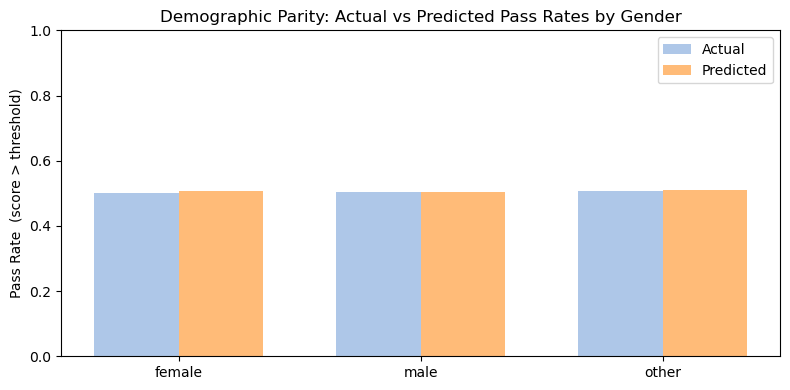

In [ ]:
#  3. DEMOGRAPHIC PARITY 
# Demographic parity: each group should have the same rate of "positive"
# predictions (predicted score above threshold), regardless of actual scores.

pass_rate_actual = {g: (y_test_arr[gender_test == g] > THRESHOLD).mean() for g in GENDERS}
pass_rate_pred   = {g: (y_pred[gender_test == g]     > THRESHOLD).mean() for g in GENDERS}

print(f"Pass/fail threshold (training mean): {THRESHOLD:.1f}")
print(f"\n{'Gender':<10} {'Actual pass rate':>18} {'Predicted pass rate':>20}")
for g in GENDERS:
    print(f"{g:<10} {pass_rate_actual[g]:>18.3f} {pass_rate_pred[g]:>20.3f}")

dp_mf = pass_rate_pred['male'] - pass_rate_pred['female']
dp_mo = pass_rate_pred['male'] - pass_rate_pred['other']
print(f"\nDemographic Parity Difference (male − female): {dp_mf:+.4f}")
print(f"Demographic Parity Difference (male − other):  {dp_mo:+.4f}")
print("Benchmark: |DP diff| < 0.05 is often considered fair  (Feldman et al., 2015)")

x = np.arange(len(GENDERS))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, [pass_rate_actual[g] for g in GENDERS], width, label='Actual',    color='#aec7e8')
ax.bar(x + width/2, [pass_rate_pred[g]   for g in GENDERS], width, label='Predicted', color='#ffbb78')
ax.set_xticks(x)
ax.set_xticklabels(GENDERS)
ax.set_ylabel("Pass Rate  (score > threshold)")
ax.set_title("Demographic Parity: Actual vs Predicted Pass Rates by Gender")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

Equal Opportunity (TPR) and False Positive Rate by Gender:
Gender          TPR      FPR  (threshold = 62.5)
female        0.868    0.142
male          0.863    0.139
other         0.874    0.137

Equal Opportunity Difference (male − female): -0.0052
Equal Opportunity Difference (male − other):  -0.0106
Benchmark: |EO diff| < 0.05  (Hardt et al., 2016)


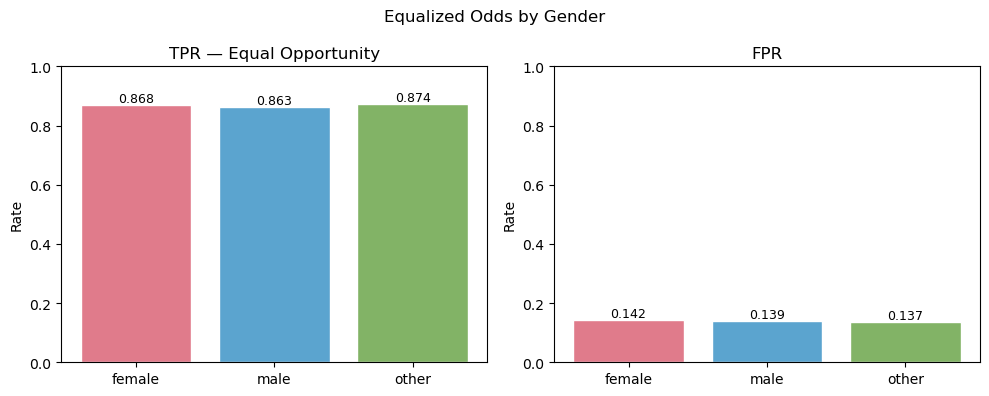

In [ ]:
#  4. EQUAL OPPORTUNITY & EQUALIZED ODDS 
# Equal opportunity: among students who ACTUALLY scored high,
# each gender should have the same rate of being PREDICTED high (TPR parity).
# Equalized odds additionally requires FPR parity.

tpr, fpr = {}, {}
for g in GENDERS:
    mask_g     = gender_test == g
    high_mask  = mask_g & (y_test_arr > THRESHOLD)
    low_mask   = mask_g & (y_test_arr <= THRESHOLD)
    tpr[g] = (y_pred[high_mask] > THRESHOLD).mean() if high_mask.sum() > 0 else np.nan
    fpr[g] = (y_pred[low_mask]  > THRESHOLD).mean() if low_mask.sum()  > 0 else np.nan

print("Equal Opportunity (TPR) and False Positive Rate by Gender:")
print(f"{'Gender':<10} {'TPR':>8} {'FPR':>8}  (threshold = {THRESHOLD:.1f})")
for g in GENDERS:
    print(f"{g:<10} {tpr[g]:>8.3f} {fpr[g]:>8.3f}")

eo_diff_mf = tpr['male'] - tpr['female']
eo_diff_mo = tpr['male'] - tpr['other']
print(f"\nEqual Opportunity Difference (male − female): {eo_diff_mf:+.4f}")
print(f"Equal Opportunity Difference (male − other):  {eo_diff_mo:+.4f}")
print("Benchmark: |EO diff| < 0.05  (Hardt et al., 2016)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (title, metric_dict) in zip(axes, [("TPR — Equal Opportunity", tpr), ("FPR", fpr)]):
    ax.bar(GENDERS, [metric_dict[g] for g in GENDERS],
           color=[palette[g] for g in GENDERS], edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel("Rate")
    ax.set_ylim(0, 1)
    for i, g in enumerate(GENDERS):
        ax.text(i, metric_dict[g] + 0.01, f'{metric_dict[g]:.3f}', ha='center', fontsize=9)
plt.suptitle("Equalized Odds by Gender", fontsize=12)
plt.tight_layout()
plt.show()

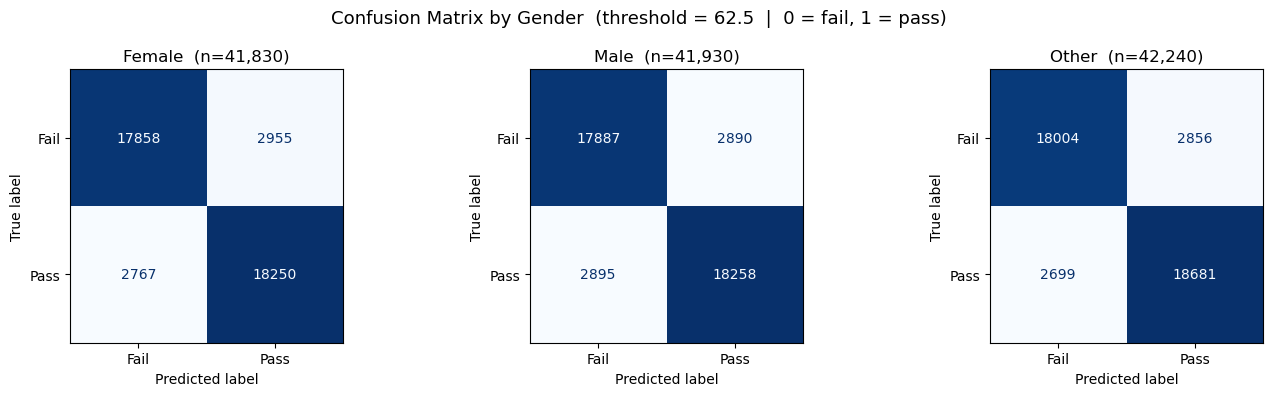


Gender         TN     FP     FN     TP      TPR     FPR    Prec      F1
--------------------------------------------------------------------
female      17858   2955   2767  18250    0.868   0.142   0.861   0.864
male        17887   2890   2895  18258    0.863   0.139   0.863   0.863
other       18004   2856   2699  18681    0.874   0.137   0.867   0.871

TPR spread (max − min): 0.0106
F1  spread (max − min): 0.0073


In [ ]:
#CONFUSION MATRIX BY GENDER GROUP 
# Binarise at THRESHOLD (training mean) → pass (1) / fail (0).
# A fair model should make similar types of errors across all groups.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_actual_bin = (y_test_arr > THRESHOLD).astype(int)
y_pred_bin   = (y_pred      > THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(
    f"Confusion Matrix by Gender  (threshold = {THRESHOLD:.1f}  |  0 = fail, 1 = pass)",
    fontsize=13
)

group_stats = []
for ax, g in zip(axes, GENDERS):
    mask = gender_test == g
    cm   = confusion_matrix(y_actual_bin[mask], y_pred_bin[mask])

    disp = ConfusionMatrixDisplay(cm, display_labels=['Fail', 'Pass'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{g.capitalize()}  (n={mask.sum():,})")

    tn, fp, fn, tp = cm.ravel()
    tpr_g  = tp / (tp + fn) if (tp + fn) > 0 else float('nan')
    fpr_g  = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
    prec_g = tp / (tp + fp) if (tp + fp) > 0 else float('nan')
    f1_g   = 2 * prec_g * tpr_g / (prec_g + tpr_g) if (prec_g + tpr_g) > 0 else float('nan')
    group_stats.append((g, tn, fp, fn, tp, tpr_g, fpr_g, prec_g, f1_g))

plt.tight_layout()
plt.show()

print(f"\n{'Gender':<10} {'TN':>6} {'FP':>6} {'FN':>6} {'TP':>6}  {'TPR':>7} {'FPR':>7} {'Prec':>7} {'F1':>7}")
print("-" * 68)
for g, tn, fp, fn, tp, tpr_g, fpr_g, prec_g, f1_g in group_stats:
    print(f"{g:<10} {tn:>6} {fp:>6} {fn:>6} {tp:>6}  {tpr_g:>7.3f} {fpr_g:>7.3f} {prec_g:>7.3f} {f1_g:>7.3f}")

tpr_list = [s[5] for s in group_stats]
f1_list  = [s[8] for s in group_stats]
print(f"\nTPR spread (max − min): {max(tpr_list) - min(tpr_list):.4f}")
print(f"F1  spread (max − min): {max(f1_list)  - min(f1_list):.4f}")

In [ ]:
#  5. COUNTERFACTUAL FAIRNESS TEST 
# Flip only gender (female ↔ male) and observe how the existing model's
# predictions change. A fair model should be insensitive to this alone.
np.random.seed(42)
sample_idx = np.random.choice(len(X_test), size=2000, replace=False)
X_sample   = X_test.iloc[sample_idx].copy()

# LabelEncoder alphabetical order: female=0, male=1
female_enc, male_enc = 0, 1

X_flipped = X_sample.copy()
X_flipped['gender'] = X_sample['gender'].apply(
    lambda g: male_enc if g == female_enc else (female_enc if g == male_enc else g)
)

pred_orig    = model.predict(X_sample)
pred_flipped = model.predict(X_flipped)
delta        = pred_flipped - pred_orig

print('Counterfactual Fairness Test — flip female ↔ male, all other features fixed (n=2,000):')
print(f'  Mean Δ:             {delta.mean():+.4f}')
print(f'  Std of Δ:           {delta.std():.4f}')
print(f'  Mean |Δ|:           {np.abs(delta).mean():.4f}')
print(f'  % with |Δ| > 1 pt: {(np.abs(delta) > 1).mean()*100:.1f}%')
print(f'  % with |Δ| > 5 pt: {(np.abs(delta) > 5).mean()*100:.1f}%')
print(f'  Max |Δ|:            {np.abs(delta).max():.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(delta, bins=60, edgecolor='white', alpha=0.8, color='#7b68ee')
ax.axvline(0,            color='red',    linestyle='--', linewidth=1.5, label='No change')
ax.axvline(delta.mean(), color='orange', linestyle='-',  linewidth=1.5, label=f'Mean Δ: {delta.mean():+.3f}')
ax.set_xlabel('Prediction Change (flipped − original)')
ax.set_ylabel('Count')
ax.set_title('Counterfactual Fairness: Δ Prediction After Gender Flip (female ↔ male)')
ax.legend()
plt.tight_layout()
plt.show()


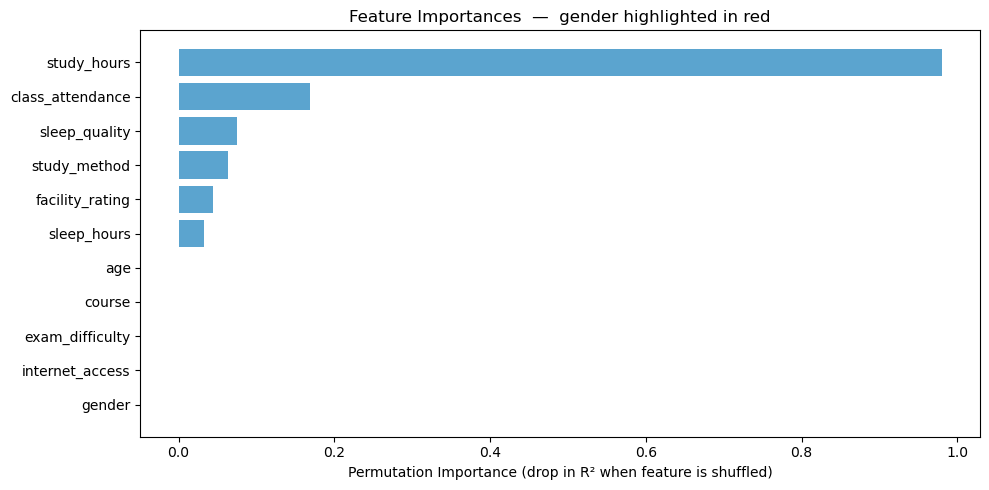


Permutation importances (ranked):
  study_hours            0.98010
  class_attendance       0.16822
  sleep_quality          0.07494
  study_method           0.06283
  facility_rating        0.04438
  sleep_hours            0.03301
  age                    0.00025
  course                 0.00024
  exam_difficulty        0.00008
  internet_access        -0.00002
  gender                 -0.00018  ← protected attribute

Gender importance rank: 11 out of 11


In [ ]:
#  6. FEATURE IMPORTANCE: Is Gender a Driver? 
# Manual permutation importance: shuffle one feature at a time, measure R² drop.
from sklearn.metrics import r2_score

feature_names = list(X_test.columns)

np.random.seed(42)
sub_idx   = np.random.choice(len(X_test), size=5000, replace=False)
X_sub     = X_test.iloc[sub_idx].reset_index(drop=True)
y_sub     = y_test.iloc[sub_idx].reset_index(drop=True)

baseline  = r2_score(y_sub, model.predict(X_sub))
imp_vals  = []
for col in feature_names:
    X_perm      = X_sub.copy()
    X_perm[col] = np.random.permutation(X_perm[col].values)
    imp_vals.append(baseline - r2_score(y_sub, model.predict(X_perm)))

importances = np.array(imp_vals)

gender_rank = np.argsort(importances)[::-1].tolist().index(feature_names.index('gender')) + 1
sorted_idx  = np.argsort(importances)
colors      = ['#e07b8b' if feature_names[i] == 'gender' else '#5ba4cf' for i in sorted_idx]

plt.figure(figsize=(10, 5))
plt.barh([feature_names[i] for i in sorted_idx], importances[sorted_idx], color=colors)
plt.xlabel("Permutation Importance (drop in R² when feature is shuffled)")
plt.title("Feature Importances  —  gender highlighted in red")
plt.tight_layout()
plt.show()

print("\nPermutation importances (ranked):")
for i in np.argsort(importances)[::-1]:
    marker = "  ← protected attribute" if feature_names[i] == 'gender' else ""
    print(f"  {feature_names[i]:<22} {importances[i]:.5f}{marker}")
print(f"\nGender importance rank: {gender_rank} out of {len(feature_names)}")

Fairness by Internet Access (proxy for socioeconomic status):
Access          n   Actual mean   Pred mean      MAE     Bias
yes       115,834         62.61       62.57     7.00    -0.04
no         10,166         62.55       62.63     6.95    +0.08

Actual score gap (yes − no internet):    +0.062
Predicted score gap (yes − no internet): -0.059
Gap amplification factor: -0.961x  (1.0 = neutral, >1.0 = model widens gap)


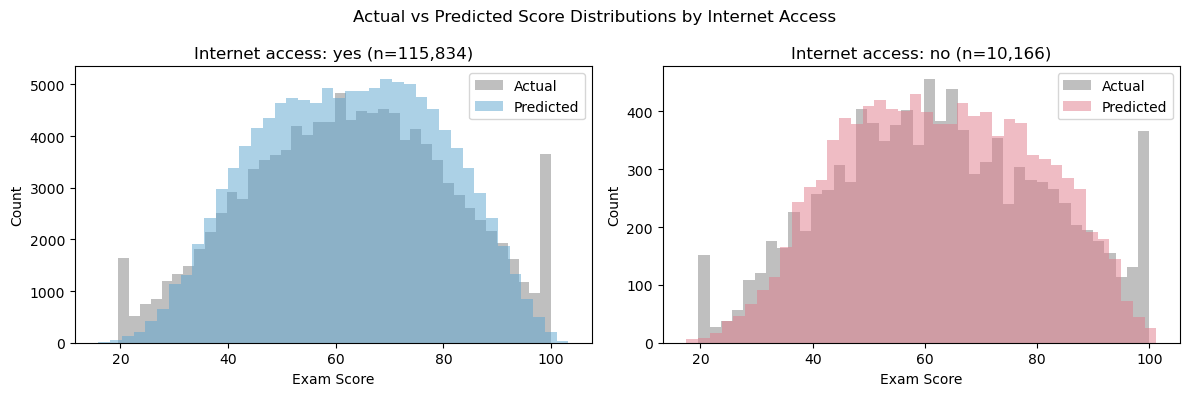

In [ ]:
#  7. SOCIOECONOMIC PROXY FAIRNESS: Internet Access 
print("Fairness by Internet Access (proxy for socioeconomic status):")
print(f"{'Access':<8} {'n':>8} {'Actual mean':>13} {'Pred mean':>11} {'MAE':>8} {'Bias':>8}")
for access in ['yes', 'no']:
    mask     = internet_test == access
    actual_m = y_test_arr[mask].mean()
    pred_m   = y_pred[mask].mean()
    mae_v    = mean_absolute_error(y_test_arr[mask], y_pred[mask])
    bias_v   = pred_m - actual_m
    print(f"{access:<8} {mask.sum():>8,} {actual_m:>13.2f} {pred_m:>11.2f} {mae_v:>8.2f} {bias_v:>+8.2f}")

actual_gap    = y_test_arr[internet_test == 'yes'].mean() - y_test_arr[internet_test == 'no'].mean()
pred_gap      = y_pred[internet_test == 'yes'].mean()     - y_pred[internet_test == 'no'].mean()
amplification = pred_gap / actual_gap if actual_gap != 0 else float('nan')

print(f"\nActual score gap (yes − no internet):    {actual_gap:+.3f}")
print(f"Predicted score gap (yes − no internet): {pred_gap:+.3f}")
print(f"Gap amplification factor: {amplification:.3f}x  (1.0 = neutral, >1.0 = model widens gap)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, access, color in zip(axes, ['yes', 'no'], ['#5ba4cf', '#e07b8b']):
    mask = internet_test == access
    ax.hist(y_test_arr[mask], bins=40, alpha=0.5, label='Actual', color='grey')
    ax.hist(y_pred[mask],     bins=40, alpha=0.5, label='Predicted', color=color)
    ax.set_title(f"Internet access: {access} (n={mask.sum():,})")
    ax.set_xlabel("Exam Score")
    ax.set_ylabel("Count")
    ax.legend()
plt.suptitle("Actual vs Predicted Score Distributions by Internet Access", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
#  FAIRNESS ANALYSIS SUMMARY 
print("=" * 65)
print("FAIRNESS ANALYSIS SUMMARY")
print("=" * 65)

rows = [
    ("Gender MAE spread (max − min)",          f"{max(mae_by_g.values()) - min(mae_by_g.values()):.3f}",     "< 1.0 suggests parity"),
    ("Gender bias spread (max − min)",          f"{max(bias_by_g.values()) - min(bias_by_g.values()):.3f}",  "close to 0 is fair"),
    ("Demographic parity diff (male − female)", f"{dp_mf:+.4f}",                                              "|diff| < 0.05 is fair"),
    ("Equal opportunity diff (male − female)",  f"{eo_diff_mf:+.4f}",                                         "|diff| < 0.05 is fair"),
    ("Counterfactual sensitivity (mean |Δ|)",   f"{np.abs(delta).mean():.4f}",                                "0 = perfectly fair"),
    ("Gender importance rank",                   f"{gender_rank} / {len(feature_names)}",                      "lower rank = less influence"),
    ("Internet access gap amplification",        f"{amplification:.3f}x",                                      "1.0 = no amplification"),
]

print(f"\n{'Metric':<46} {'Value':>12}  {'Benchmark'}")
print("-" * 76)
for metric, value, bench in rows:
    print(f"{metric:<46} {value:>12}  {bench}")

print("\nKey references:")
print("  Feldman et al. (2015) - Certifying and Removing Disparate Impact")
print("  Hardt, Price, Srebro (2016) - Equality of Opportunity in Supervised Learning")

FAIRNESS ANALYSIS SUMMARY

Metric                                                Value  Benchmark
----------------------------------------------------------------------------
Gender MAE spread (max − min)                         0.023  < 1.0 suggests parity
Gender bias spread (max − min)                        0.062  close to 0 is fair
Demographic parity diff (male − female)             -0.0026  |diff| < 0.05 is fair
Equal opportunity diff (male − female)              -0.0052  |diff| < 0.05 is fair
Counterfactual sensitivity (mean |Δ|)                0.0686  0 = perfectly fair
Gender importance rank                              11 / 11  lower rank = less influence
Internet access gap amplification                   -0.961x  1.0 = no amplification

Key references:
  Feldman et al. (2015) - Certifying and Removing Disparate Impact
  Hardt, Price, Srebro (2016) - Equality of Opportunity in Supervised Learning


# SHAP Analysis

In [ ]:
import shap

# TreeExplainer is exact and fast for gradient boosted trees
explainer_shap = shap.TreeExplainer(model)

# Compute on a 2000-row sample — full test set is 126k rows and would be slow
np.random.seed(42)
shap_idx    = np.random.choice(len(X_test), size=2000, replace=False)
X_shap      = X_test.iloc[shap_idx].reset_index(drop=True)
shap_values = explainer_shap(X_shap)

print(f'SHAP values computed for {len(X_shap):,} test samples')
print(f'Shape: {shap_values.values.shape}  (samples x features)')
print(f'Features: {list(X_shap.columns)}')


In [ ]:
# Global importance: mean |SHAP| bar chart
shap.plots.bar(shap_values, max_display=16)

# Beeswarm: shows both magnitude and direction of each feature's effect
shap.plots.beeswarm(shap_values, max_display=16)

In [ ]:
# Dependence plots for the two strongest features
for feature in ['study_hours', 'class_attendance']:
    shap.plots.scatter(shap_values[:, feature], color=shap_values)


In [ ]:
def explain_student(student: dict):
    """
    Predict and explain a single student's exam score using SHAP.

    Parameters
    ----------
    student : dict with raw (unencoded) feature values

    Example
    -------
    explain_student({
        'age': 21, 'gender': 'female', 'course': 'Engineering',
        'study_hours': 5.0, 'class_attendance': 80.0,
        'internet_access': 'yes', 'sleep_hours': 7.0,
        'sleep_quality': 'good', 'study_method': 'visual',
        'facility_rating': 'average', 'exam_difficulty': 'medium'
    })
    """
    raw_df = pd.DataFrame([student])
    for col in _cat:
        raw_df[col] = _le.transform(raw_df[col])
    pred = model.predict(raw_df)[0]
    sv   = explainer_shap(raw_df)
    print(f'Predicted exam score: {pred:.1f}  (model baseline: {sv.base_values[0]:.1f})')
    shap.plots.waterfall(sv[0])
